In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import timedelta

import os, random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True)
except Exception as e:
    print("Non-deterministic op detected:", e)



df = pd.read_excel("/Users/m/Desktop/Final project/General Surgery/ngs3.xlsx", sheet_name="Sheet1")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
print(df.head())

        Date  Bed Occupancy
0 2017-01-01             51
1 2017-01-02             58
2 2017-01-03             58
3 2017-01-04             71
4 2017-01-05             63


In [3]:

# Step 2: 
values = df['Bed Occupancy'].values.astype(np.float32)
min_val, max_val = values.min(), values.max()
values_normalized = (values - min_val) / (max_val - min_val)

# Step 3: 
sequence_length = 730
predict_length = 10
target_start = pd.to_datetime("2019-01-01")
target_end = pd.to_datetime("2020-02-29")

X_all, y_all, forecast_dates = [], [], []
i = 0
while i + sequence_length + predict_length <= len(values):
    input_start = i
    input_end = i + sequence_length
    forecast_start = df['Date'].iloc[input_end]
    
    if forecast_start > target_end:
        break
    if forecast_start >= target_start:
        X_all.append(values_normalized[input_start:input_end])
        y_all.append(values_normalized[input_end:input_end + predict_length])
        forecast_dates.append(forecast_start)
    
    i += predict_length  

X_tensor = torch.tensor(np.array(X_all)).unsqueeze(-1)  # [N, 730, 1]
y_tensor = torch.tensor(np.array(y_all))                # [N, 10]



In [6]:
# Step 4:  LSTM 
class ForecastLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=10):
        super(ForecastLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = ForecastLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)



# Step 5: 
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()



In [7]:
# Step 6: 
model.eval()
with torch.no_grad():
    predictions = model(X_tensor).numpy()

predictions_denorm = predictions * (max_val - min_val) + min_val
actuals_denorm = y_tensor.numpy() * (max_val - min_val) + min_val

# Step 7: 
merged_dates, merged_preds, merged_actuals = [], [], []
for i in range(len(predictions_denorm)):
    for j in range(predict_length):
        merged_dates.append(forecast_dates[i] + timedelta(days=j))
        merged_preds.append(predictions_denorm[i][j])
        merged_actuals.append(actuals_denorm[i][j])

In [8]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import numpy as np


# --- train/val split ---
idx = np.arange(len(X_tensor))
train_idx, val_idx = train_test_split(idx, test_size=0.2, random_state=42, shuffle=True)

X_train, y_train = X_tensor[train_idx], y_tensor[train_idx]
X_val,   y_val   = X_tensor[val_idx],   y_tensor[val_idx]


# --- LSTM model ---
class ForecastLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=10):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)          # [B, T, H]
        last_h = out[:, -1, :]         
        return self.fc(last_h)         # -> [B, output_size]


# --- define MAPE ---
def mape(y_true, y_pred, eps=1e-8):
    """
    Mean Absolute Percentage Error
    y_true, y_pred: torch.Tensor of same shape
    """
    return torch.mean(torch.abs((y_true - y_pred) / (y_true + eps))) * 100


# --- training function ---
def train_one_model(hidden_size, num_layers, epochs=50, lr=1e-3, verbose=False):
    model = ForecastLSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, output_size=10)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(X_train)
        loss = criterion(pred, y_train)
        loss.backward()
        optimizer.step()

        if verbose and (ep+1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_loss = criterion(val_pred, y_val).item()
                val_mape = mape(y_val, val_pred).item()
            print(f"[{ep+1:03d}] train_loss={loss.item():.6f}  val_loss={val_loss:.6f}  val_mape={val_mape:.2f}%")

    # final eval
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val).item()
        val_mape = mape(y_val, val_pred).item()
    return val_loss, val_mape, model


# --- hyperparam search ---
hidden_sizes = [32, 64, 128]
num_layers_list = [1, 2, 3]
epochs = 60
lr = 1e-3

best = {"val_loss": float("inf"), "val_mape": None, "hidden_size": None, "num_layers": None, "model": None}

for hs in hidden_sizes:
    for nl in num_layers_list:
        val_loss, val_mape, model = train_one_model(hs, nl, epochs=epochs, lr=lr, verbose=False)
        print(f"hs={hs:3d}, layers={nl}: val_loss={val_loss:.6f}, val_mape={val_mape:.2f}%")
        if val_loss < best["val_loss"]:
            best = {"val_loss": val_loss, "val_mape": val_mape, "hidden_size": hs, "num_layers": nl, "model": model}

print("\nBest setting -> hidden_size={}, num_layers={}, val_loss={:.6f}, val_mape={:.2f}%"
      .format(best["hidden_size"], best["num_layers"], best["val_loss"], best["val_mape"]))

best_model = best["model"]


hs= 32, layers=1: val_loss=0.017209, val_mape=18.96%
hs= 32, layers=2: val_loss=0.016895, val_mape=20.50%
hs= 32, layers=3: val_loss=0.016825, val_mape=20.63%
hs= 64, layers=1: val_loss=0.016439, val_mape=20.57%
hs= 64, layers=2: val_loss=0.016110, val_mape=19.34%
hs= 64, layers=3: val_loss=0.016130, val_mape=19.99%
hs=128, layers=1: val_loss=0.016250, val_mape=18.75%
hs=128, layers=2: val_loss=0.015973, val_mape=19.95%
hs=128, layers=3: val_loss=0.016225, val_mape=19.64%

Best setting -> hidden_size=128, num_layers=2, val_loss=0.015973, val_mape=19.95%


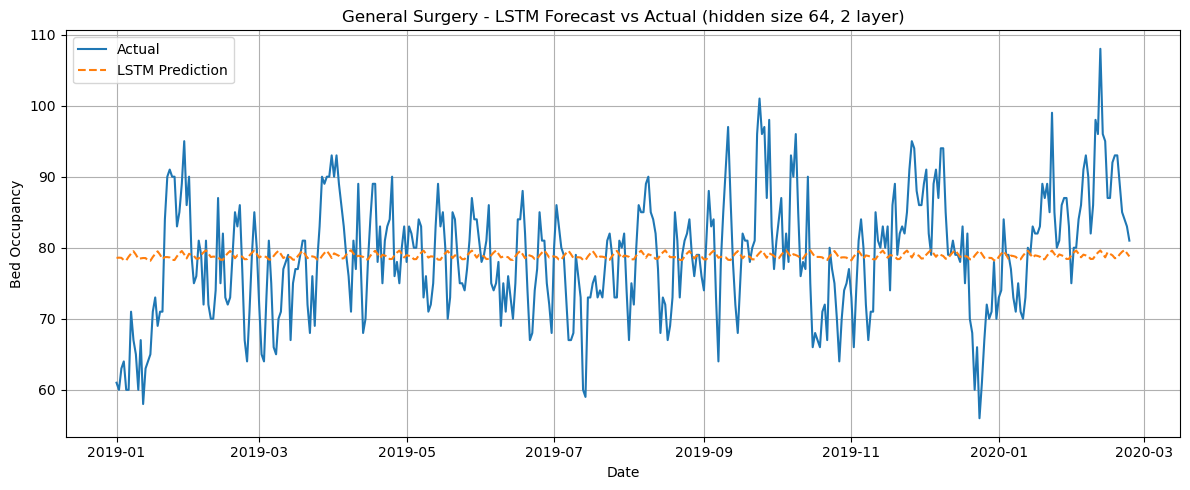

In [593]:

# Step 8: 
# hidden size 64, 2 layer
plt.figure(figsize=(12, 5))
plt.plot(merged_dates, merged_actuals, label="Actual")
plt.plot(merged_dates, merged_preds, label="LSTM Prediction", linestyle='--')
plt.title("General Surgery - LSTM Forecast vs Actual (hidden size 64, 2 layer)")
plt.xlabel("Date")
plt.ylabel("Bed Occupancy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("gsLSTM1.png", dpi=300, bbox_inches="tight")
plt.show()

In [565]:
# Step 9: Metrics (RMSE, MAE, MAPE, R2)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd


y_true = np.array(merged_actuals, dtype=float)
y_pred = np.array(merged_preds, dtype=float)


mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)


mask = y_true != 0
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

r2   = r2_score(y_true, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.4f}")


MSE : 69.7485
RMSE: 8.3516
MAE : 6.6709
MAPE: 8.66%
R²  : 0.0122


In [22]:
# hidden size 128, 2 layer
class ForecastLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=10):
        super(ForecastLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = ForecastLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Step 5: 
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()


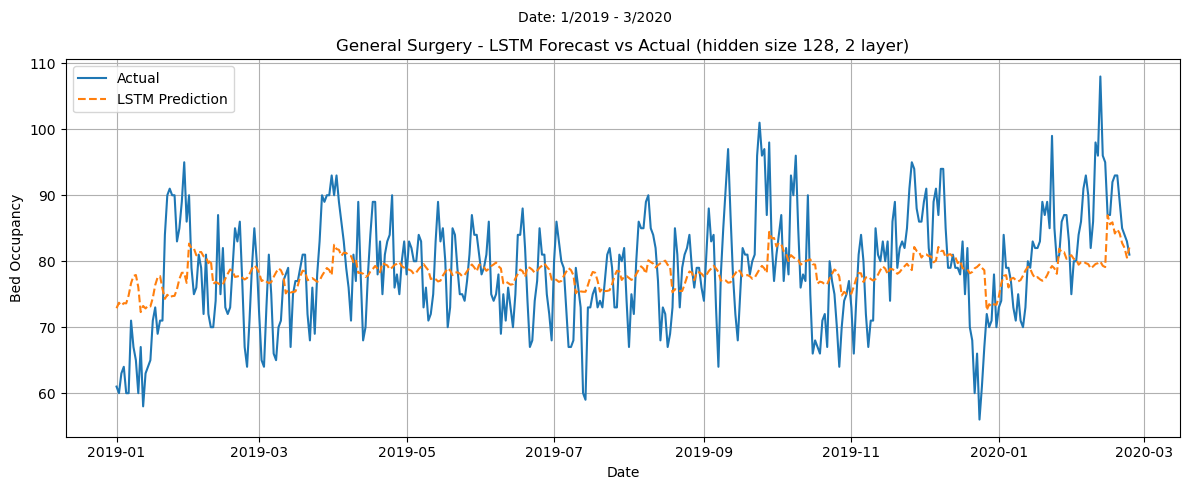

In [23]:
# hidden size 128, 2 layer
model.eval()
with torch.no_grad():
    predictions = model(X_tensor).numpy()

predictions_denorm = predictions * (max_val - min_val) + min_val
actuals_denorm = y_tensor.numpy() * (max_val - min_val) + min_val

# Step  
merged_dates, merged_preds, merged_actuals = [], [], []
for i in range(len(predictions_denorm)):
    for j in range(predict_length):
        merged_dates.append(forecast_dates[i] + timedelta(days=j))
        merged_preds.append(predictions_denorm[i][j])
        merged_actuals.append(actuals_denorm[i][j])

# Step  
plt.figure(figsize=(12, 5))
plt.plot(merged_dates, merged_actuals, label="Actual")
plt.plot(merged_dates, merged_preds, label="LSTM Prediction", linestyle='--')
plt.title("General Surgery - LSTM Forecast vs Actual (hidden size 128, 2 layer)")
plt.suptitle("Date: 1/2019 - 3/2020", y=0.97, fontsize=10)
plt.xlabel("Date")
plt.ylabel("Bed Occupancy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("gsLSTM2.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# hidden size 128, 2 layer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd


y_true = np.array(merged_actuals, dtype=float)
y_pred = np.array(merged_preds, dtype=float)


mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)


mask = y_true != 0
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

r2   = r2_score(y_true, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.4f}")


MSE : 60.0525
RMSE: 7.7494
MAE : 6.1797
MAPE: 7.95%
R²  : 0.1495


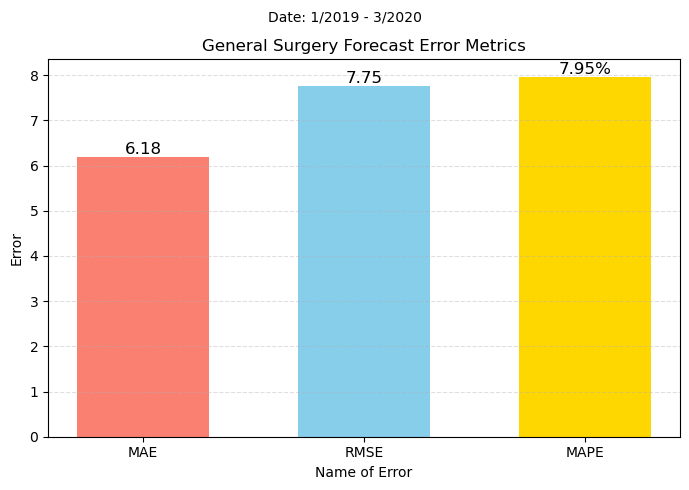

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) compute metrics ---
y_true = np.asarray(merged_actuals, dtype=float)
y_pred = np.asarray(merged_preds,   dtype=float)

mae  = float(np.mean(np.abs(y_true - y_pred)))
rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
mape = float(np.nanmean(np.abs((y_true - y_pred) / np.where(y_true==0, np.nan, y_true))) * 100)

# --- 2) build dataframe ---
metric_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value":  [mae, rmse, mape],
    "Color":  ["salmon", "skyblue", "gold"]
})

# --- 3) plot ---
plt.figure(figsize=(7,5))
bars = plt.bar(metric_df["Metric"], metric_df["Value"],
               color=metric_df["Color"], width=0.6)

# add value labels (MAPE with % sign, others raw numbers)
for metric, b, v in zip(metric_df["Metric"], bars, metric_df["Value"]):
    if metric == "MAPE":
        label = f"{v:.2f}%"
    else:
        label = f"{v:.2f}"
    plt.text(b.get_x() + b.get_width()/2, b.get_height(),
             label, ha="center", va="bottom", fontsize=12)

plt.title("General Surgery Forecast Error Metrics")
plt.suptitle("Date: 1/2019 - 3/2020", y=0.97, fontsize=10)
plt.xlabel("Name of Error")
plt.ylabel("Error")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()


plt.savefig("GS_error_metrics_mixed.png", dpi=300, bbox_inches="tight")
plt.show()


In [30]:
# === Export to Excel: Actual vs Forecast ===
import pandas as pd
import numpy as np

df_out = pd.DataFrame({
    "Date": merged_dates,
    "Actual": np.asarray(merged_actuals, dtype=float),
    "Forecast": np.asarray(merged_preds, dtype=float),
})

 
df_out["AbsError"] = (df_out["Actual"] - df_out["Forecast"]).abs()

df_out["PctError(%)"] = np.where(
    df_out["Actual"] == 0,
    np.nan,
    (df_out["AbsError"] / df_out["Actual"]) * 100
)


# df_out = df_out.groupby("Date", as_index=False).mean(numeric_only=True)


excel_path = "GeneralSurgery_LSTM_Actual_vs_Forecast.xlsx"
df_out.to_excel(excel_path, index=False)
print(f"Saved: {excel_path}")

Saved: GeneralSurgery_LSTM_Actual_vs_Forecast.xlsx


In [40]:
# Step 2: 
values = df['Bed Occupancy'].values.astype(np.float32)
min_val, max_val = values.min(), values.max()
values_normalized = (values - min_val) / (max_val - min_val)

# Step 3: 
sequence_length = 365
predict_length = 10
target_start = pd.to_datetime("2018-01-01")
target_end = pd.to_datetime("2020-02-29")

X_all, y_all, forecast_dates = [], [], []
i = 0
while i + sequence_length + predict_length <= len(values):
    input_start = i
    input_end = i + sequence_length
    forecast_start = df['Date'].iloc[input_end]
    
    if forecast_start > target_end:
        break
    if forecast_start >= target_start:
        X_all.append(values_normalized[input_start:input_end])
        y_all.append(values_normalized[input_end:input_end + predict_length])
        forecast_dates.append(forecast_start)
    
    i += predict_length  

X_tensor = torch.tensor(np.array(X_all)).unsqueeze(-1)  # [N, 730, 1]
y_tensor = torch.tensor(np.array(y_all))                # [N, 10]



In [46]:
# hidden size 128, 2 layer
class ForecastLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=10):
        super(ForecastLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = ForecastLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Step 5: 
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()


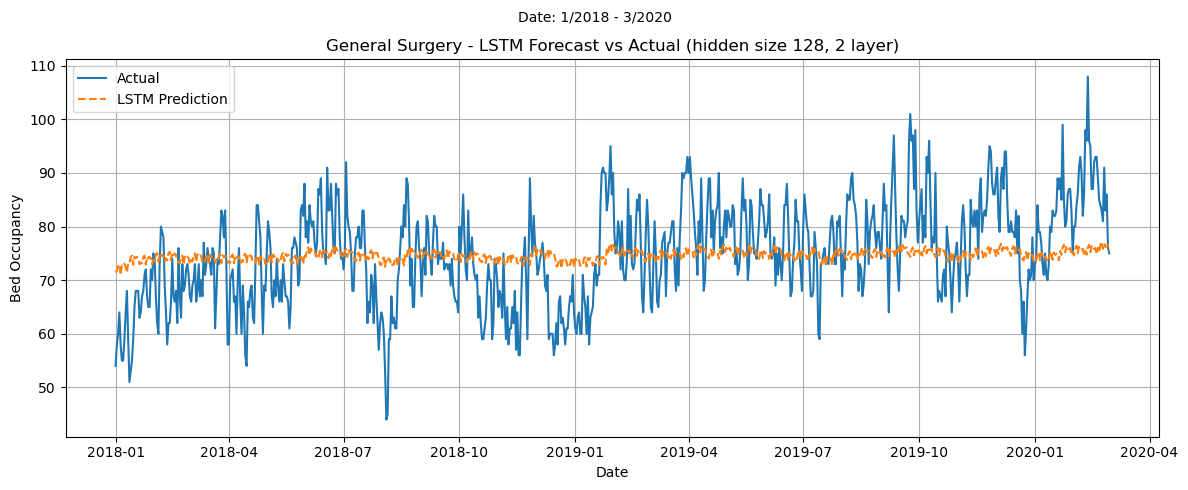

In [60]:
# hidden size 128, 2 layer
model.eval()
with torch.no_grad():
    predictions = model(X_tensor).numpy()

predictions_denorm = predictions * (max_val - min_val) + min_val
actuals_denorm = y_tensor.numpy() * (max_val - min_val) + min_val

# Step  
merged_dates, merged_preds, merged_actuals = [], [], []
for i in range(len(predictions_denorm)):
    for j in range(predict_length):
        merged_dates.append(forecast_dates[i] + timedelta(days=j))
        merged_preds.append(predictions_denorm[i][j])
        merged_actuals.append(actuals_denorm[i][j])

# Step  
plt.figure(figsize=(12, 5))
plt.plot(merged_dates, merged_actuals, label="Actual")
plt.plot(merged_dates, merged_preds, label="LSTM Prediction", linestyle='--')
plt.title("General Surgery - LSTM Forecast vs Actual (hidden size 128, 2 layer)")
plt.suptitle("Date: 1/2018 - 3/2020", y=0.97, fontsize=10)
plt.xlabel("Date")
plt.ylabel("Bed Occupancy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("gsLSTM4.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
# hidden size 128, 2 layer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd


y_true = np.array(merged_actuals, dtype=float)
y_pred = np.array(merged_preds, dtype=float)


mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)


mask = y_true != 0
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

r2   = r2_score(y_true, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.4f}")

MSE : 79.7627
RMSE: 8.9310
MAE : 7.1736
MAPE: 9.83%
R²  : 0.0863


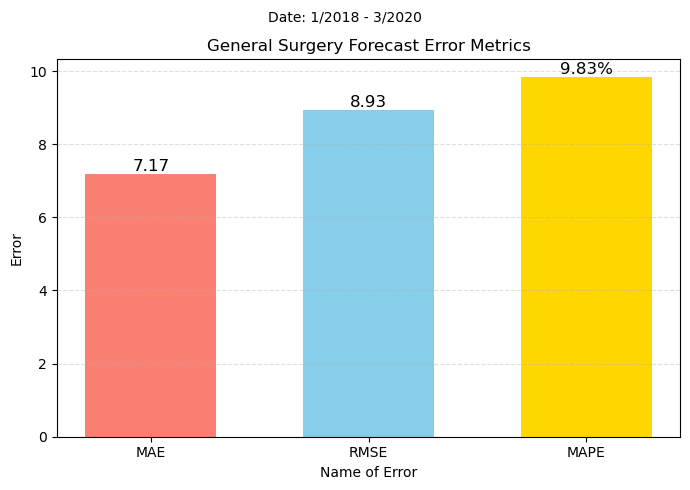

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) compute metrics ---
y_true = np.asarray(merged_actuals, dtype=float)
y_pred = np.asarray(merged_preds,   dtype=float)

mae  = float(np.mean(np.abs(y_true - y_pred)))
rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
mape = float(np.nanmean(np.abs((y_true - y_pred) / np.where(y_true==0, np.nan, y_true))) * 100)

# --- 2) build dataframe ---
metric_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value":  [mae, rmse, mape],
    "Color":  ["salmon", "skyblue", "gold"]
})

# --- 3) plot ---
plt.figure(figsize=(7,5))
bars = plt.bar(metric_df["Metric"], metric_df["Value"],
               color=metric_df["Color"], width=0.6)

# add value labels (MAPE with % sign, others raw numbers)
for metric, b, v in zip(metric_df["Metric"], bars, metric_df["Value"]):
    if metric == "MAPE":
        label = f"{v:.2f}%"
    else:
        label = f"{v:.2f}"
    plt.text(b.get_x() + b.get_width()/2, b.get_height(),
             label, ha="center", va="bottom", fontsize=12)

plt.title("General Surgery Forecast Error Metrics")
plt.suptitle("Date: 1/2018 - 3/2020", y=0.97, fontsize=10)
plt.xlabel("Name of Error")
plt.ylabel("Error")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("GS_error_metrics_mixed2.png", dpi=300, bbox_inches="tight")
plt.show()


In [573]:
# hidden size 128, 1 layer
class ForecastLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=1, output_size=10):
        super(ForecastLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = ForecastLSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Step 5: 
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()


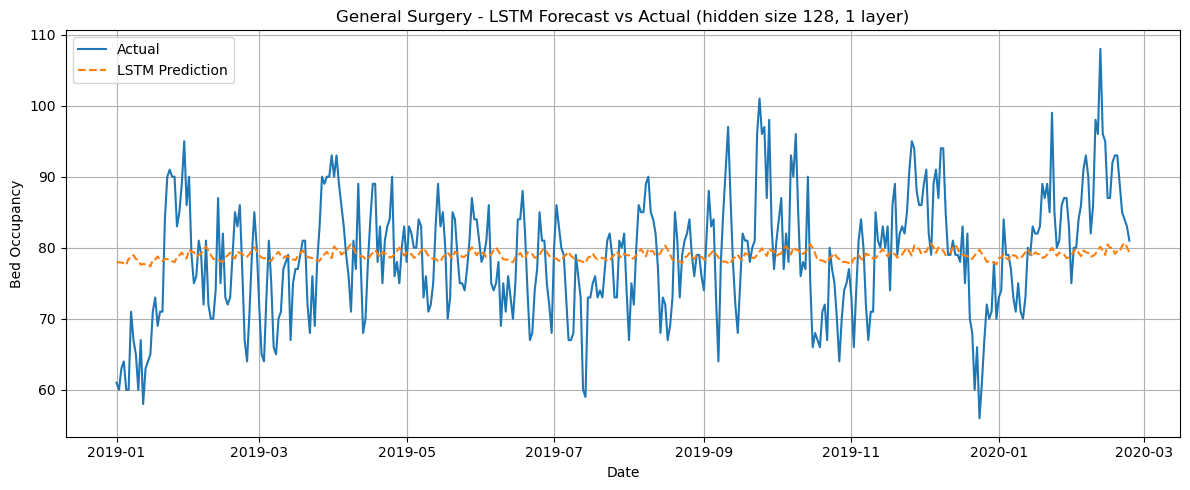

In [574]:
# hidden size 128, 1 layer
model.eval()
with torch.no_grad():
    predictions = model(X_tensor).numpy()

predictions_denorm = predictions * (max_val - min_val) + min_val
actuals_denorm = y_tensor.numpy() * (max_val - min_val) + min_val

# Step  
merged_dates, merged_preds, merged_actuals = [], [], []
for i in range(len(predictions_denorm)):
    for j in range(predict_length):
        merged_dates.append(forecast_dates[i] + timedelta(days=j))
        merged_preds.append(predictions_denorm[i][j])
        merged_actuals.append(actuals_denorm[i][j])

# Step  
plt.figure(figsize=(12, 5))
plt.plot(merged_dates, merged_actuals, label="Actual")
plt.plot(merged_dates, merged_preds, label="LSTM Prediction", linestyle='--')
plt.title("General Surgery - LSTM Forecast vs Actual (hidden size 128, 1 layer)")
plt.xlabel("Date")
plt.ylabel("Bed Occupancy")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("gsLSTM3.png", dpi=300, bbox_inches="tight")
plt.show()

In [577]:
# hidden size 128, 1 layer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 
y_true = np.array(merged_actuals, dtype=float)
y_pred = np.array(merged_preds, dtype=float)

# 
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)

# 
mask = y_true != 0
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if np.any(mask) else np.nan

r2   = r2_score(y_true, y_pred)

print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.4f}")


MSE : 67.2101
RMSE: 8.1982
MAE : 6.5495
MAPE: 8.51%
R²  : 0.0482
